In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = "/content/drive/MyDrive/Banking_FinTech_Project"

print("Project Exists:", os.path.exists(project_path))

Project Exists: True


In [3]:
import pandas as pd

path = "/content/drive/MyDrive/Banking_FinTech_Project/dataset/fraudTrain.csv"

df = pd.read_csv(path)

print(df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

# Banking Dataset Exploration

In [4]:
import pandas as pd
import numpy as np

In [5]:
path = "/content/drive/MyDrive/Banking_FinTech_Project/dataset/fraudTrain.csv"

df = pd.read_csv(path)

In [6]:
print(df.shape)

(1296675, 23)


In [7]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
print(df.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [13]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [14]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


In [15]:
fraud_percent = df['is_fraud'].value_counts(normalize=True) * 100

print(fraud_percent)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


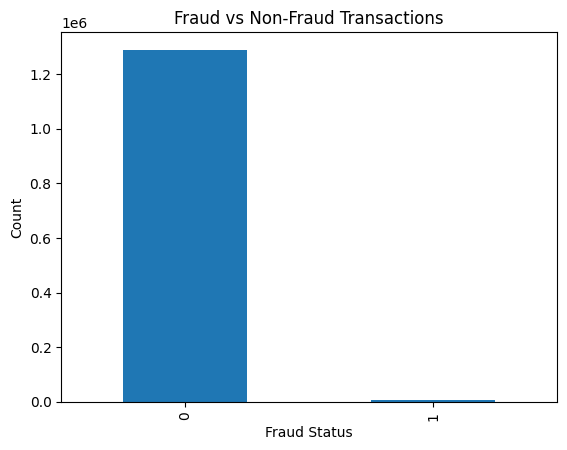

In [16]:
import matplotlib.pyplot as plt

df['is_fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

In [17]:
df['category'].value_counts().head(10)

,count
category,
gas_transport,131659
grocery_pos,123638
home,123115
shopping_pos,116672
kids_pets,113035
shopping_net,97543
entertainment,94014
food_dining,91461
personal_care,90758


In [18]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

print("Date column converted successfully")

Date column converted successfully


In [19]:
df['Year'] = df['trans_date_trans_time'].dt.year
df['Month'] = df['trans_date_trans_time'].dt.month
df['Day'] = df['trans_date_trans_time'].dt.day
df['Hour'] = df['trans_date_trans_time'].dt.hour

print("New columns created successfully")

New columns created successfully


In [20]:
df[['trans_date_trans_time', 'Year', 'Month', 'Day', 'Hour']].head()

,trans_date_trans_time,Year,Month,Day,Hour
0,2019-01-01 00:00:18,2019,1,1,0
1,2019-01-01 00:00:44,2019,1,1,0
2,2019-01-01 00:00:51,2019,1,1,0
3,2019-01-01 00:01:16,2019,1,1,0
4,2019-01-01 00:03:06,2019,1,1,0


In [21]:
import sqlite3

In [22]:
db_path = "/content/drive/MyDrive/Banking_FinTech_Project/sql/banking_fintech.db"

conn = sqlite3.connect(db_path)

print("Database Connected Successfully")

Database Connected Successfully


In [23]:
df.to_sql('bank_transactions', conn, if_exists='replace', index=False)

print("Dataset inserted into SQL table successfully")

Dataset inserted into SQL table successfully


In [24]:
query = "SELECT * FROM bank_transactions LIMIT 5"

sql_df = pd.read_sql(query, conn)

sql_df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Year,Month,Day,Hour
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019,1,1,0


In [25]:
query = """
SELECT COUNT(*) AS Total_Transactions
FROM bank_transactions
"""

result = pd.read_sql(query, conn)

result

,Total_Transactions
0,1296675


In [26]:
query = """
SELECT COUNT(*) AS Fraud_Transactions
FROM bank_transactions
WHERE is_fraud = 1
"""

result = pd.read_sql(query, conn)

result

,Fraud_Transactions
0,7506


In [27]:
query = """
SELECT
    ROUND(
        (SUM(is_fraud) * 100.0 / COUNT(*)),
        2
    ) AS Fraud_Percentage
FROM bank_transactions
"""

result = pd.read_sql(query, conn)

result

,Fraud_Percentage
0,0.58


In [28]:
query = """
SELECT
    category,
    COUNT(*) AS Total_Transactions
FROM bank_transactions
GROUP BY category
ORDER BY Total_Transactions DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

result

,category,Total_Transactions
0,gas_transport,131659
1,grocery_pos,123638
2,home,123115
3,shopping_pos,116672
4,kids_pets,113035
5,shopping_net,97543
6,entertainment,94014
7,food_dining,91461
8,personal_care,90758
9,health_fitness,85879


In [29]:
query = """
SELECT
    state,
    COUNT(*) AS Total_Transactions
FROM bank_transactions
GROUP BY state
ORDER BY Total_Transactions DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

result

,state,Total_Transactions
0,TX,94876
1,NY,83501
2,PA,79847
3,CA,56360
4,OH,46480
5,MI,46154
6,IL,43252
7,FL,42671
8,AL,40989
9,MO,38403


In [30]:
query = """
SELECT
    category,
    COUNT(*) AS Fraud_Count
FROM bank_transactions
WHERE is_fraud = 1
GROUP BY category
ORDER BY Fraud_Count DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)

result

,category,Fraud_Count
0,grocery_pos,1743
1,shopping_net,1713
2,misc_net,915
3,shopping_pos,843
4,gas_transport,618
5,misc_pos,250
6,kids_pets,239
7,entertainment,233
8,personal_care,220
9,home,198


In [31]:
query = """
SELECT
    ROUND(AVG(amt), 2) AS Average_Transaction_Amount
FROM bank_transactions
"""

result = pd.read_sql(query, conn)

result

,Average_Transaction_Amount
0,70.35


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

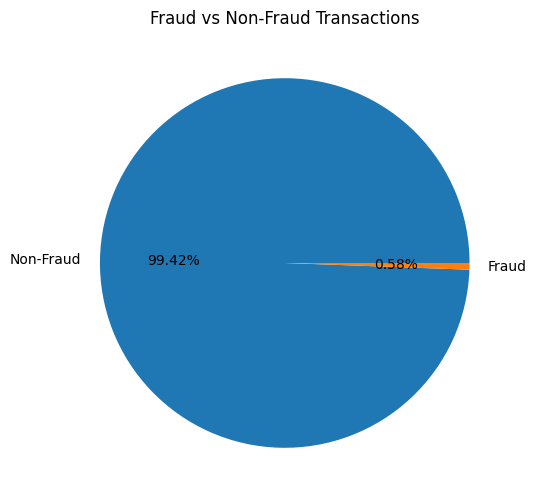

In [33]:
fraud_counts = df['is_fraud'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.2f%%'
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

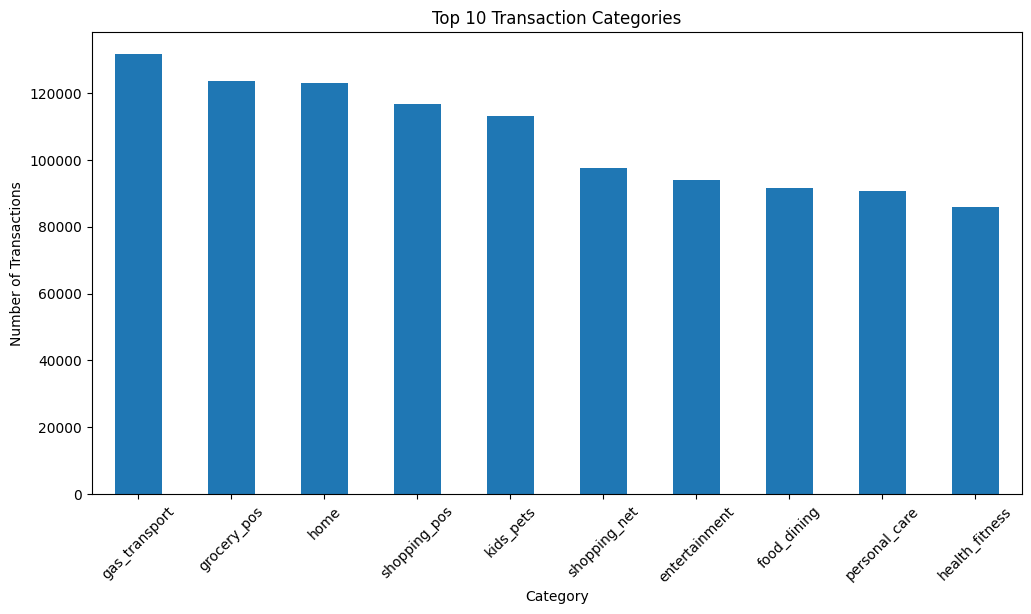

In [34]:
top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_categories.plot(kind='bar')

plt.title("Top 10 Transaction Categories")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

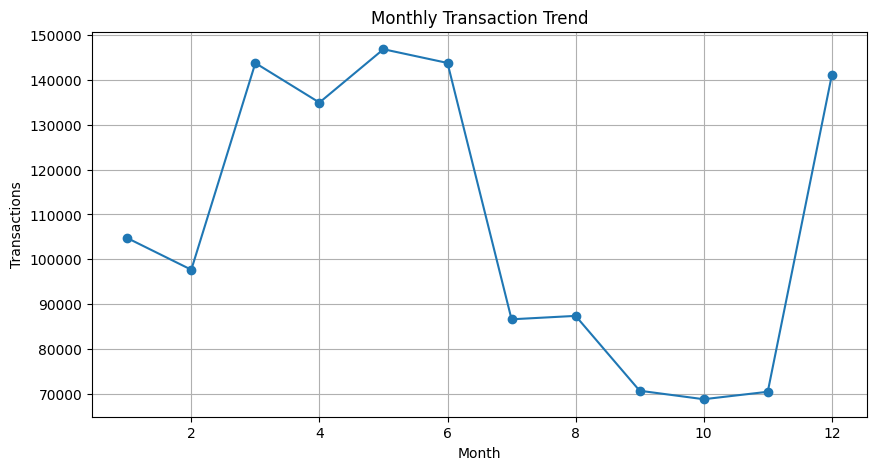

In [35]:
monthly_transactions = df.groupby('Month').size()

plt.figure(figsize=(10,5))

monthly_transactions.plot(marker='o')

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.grid()

plt.show()

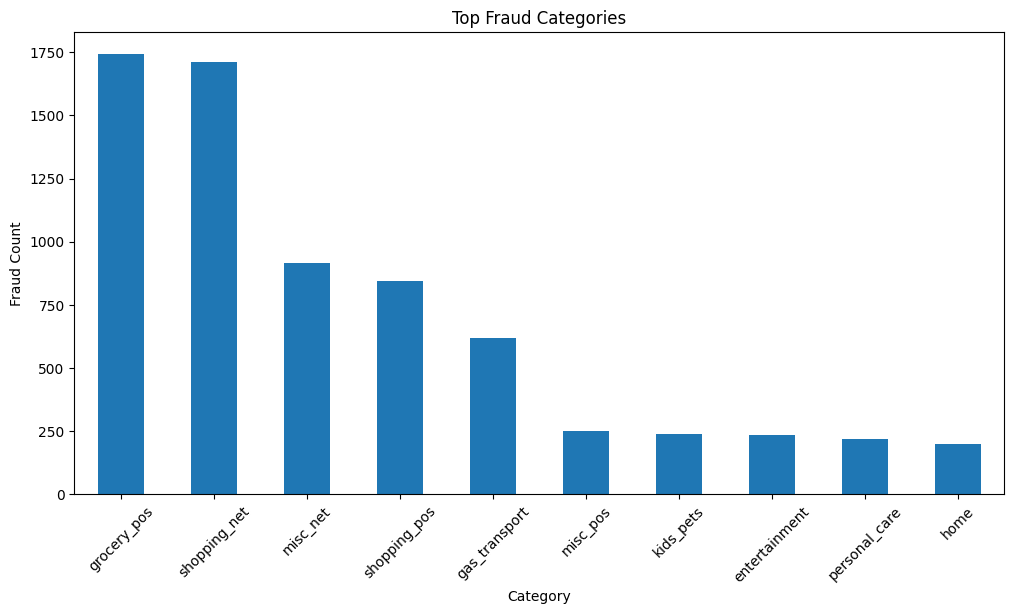

In [36]:
fraud_category = df[df['is_fraud'] == 1]['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

fraud_category.plot(kind='bar')

plt.title("Top Fraud Categories")
plt.xlabel("Category")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

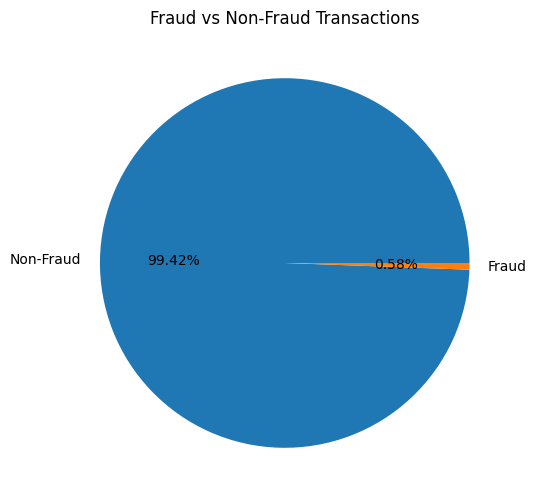

Chart Saved Successfully


In [37]:
plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.2f%%'
)

plt.title("Fraud vs Non-Fraud Transactions")

save_path = "/content/drive/MyDrive/Banking_FinTech_Project/images/fraud_pie_chart.png"

plt.savefig(save_path)

plt.show()

print("Chart Saved Successfully")

In [38]:
export_path = "/content/drive/MyDrive/Banking_FinTech_Project/powerbi/banking_cleaned_data.csv"

df.to_csv(export_path, index=False)

print("Dataset Exported Successfully")

Dataset Exported Successfully
